# **02 - Data Exploration and Visual Frame Analysis**

This notebook documents the first visual inspection stage of the Nexar Collision Prediction dataset. The goal is to understand what the model may see before collision or near-collision events, and to generate article-ready evidence before training a baseline.

## **Experimental Role**

This notebook complements `01_nexar_end_to_end_experiment.ipynb`. The first notebook is the broad project overview; this one focuses on sampled videos, extracted frames, and visual analysis.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

sample_csv = INTERIM_DATA_DIR / "sample_100_videos.csv"
frames_manifest_csv = INTERIM_DATA_DIR / "sample_frames_manifest.csv"

sample_csv, frames_manifest_csv

(WindowsPath('c:/Users/z004hn4c/Documents/Estudo/LLMOps And AIOps Bootcamp With 8 End To End Projects/nexar-dashcam-collision-prediction/data/interim/sample_100_videos.csv'),
 WindowsPath('c:/Users/z004hn4c/Documents/Estudo/LLMOps And AIOps Bootcamp With 8 End To End Projects/nexar-dashcam-collision-prediction/data/interim/sample_frames_manifest.csv'))

## **Sampled Videos**

The sample is stratified: 50 positive and 50 negative training videos. This allows a small, controlled first inspection without processing the full dataset.

In [2]:
sample_df = pd.read_csv(sample_csv, dtype={"id": str})

display(sample_df.head())
sample_df["target"].value_counts().sort_index()

,id,time_of_event,time_of_alert,target,video_path,split
0,01840,NaN,NaN,0,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,train_sample
1,01372,NaN,NaN,0,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,train_sample
2,01985,NaN,NaN,0,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,train_sample
3,00364,20.427,19.447,1,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,train_sample
4,00610,21.068,18.431,1,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,train_sample


target
0    50
1    50
Name: count, dtype: int64

## **Extracted Frames Manifest**

Positive videos are sampled around `time_of_alert` and `time_of_event`. Negative videos are sampled at fixed relative positions across the video duration.

In [3]:
frames_df = pd.read_csv(frames_manifest_csv, dtype={"id": str})

display(frames_df.head())
frames_df.groupby(["target", "frame_label"]).size().unstack(fill_value=0)

,id,target,frame_label,timestamp,frame_path,fps,duration,frame_count
0,01840,0,video_20pct,8.180,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227
1,01840,0,video_40pct,16.360,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227
2,01840,0,video_60pct,24.540,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227
3,01840,0,video_80pct,32.720,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227
4,01840,0,video_95pct,38.855,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227


frame_label,alert,event,event_minus_1s,event_minus_3s,event_minus_5s,video_20pct,video_40pct,video_60pct,video_80pct,video_95pct
target,,,,,,,,,,
0,0,0,0,0,0,50,50,50,50,50
1,50,50,50,50,50,0,0,0,0,0


## **Example Timelines**

The figures below show representative frame timelines for one positive and one negative sample. These figures are useful for qualitative analysis and for motivating the scientific framing of early risk anticipation.

negative_timeline_01840.png


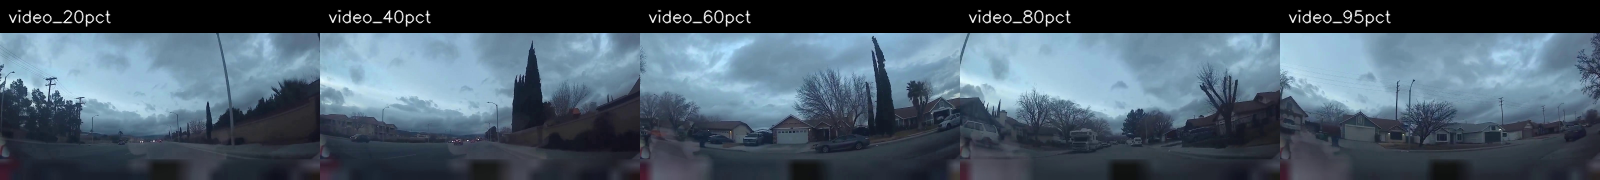

positive_timeline_00364.png


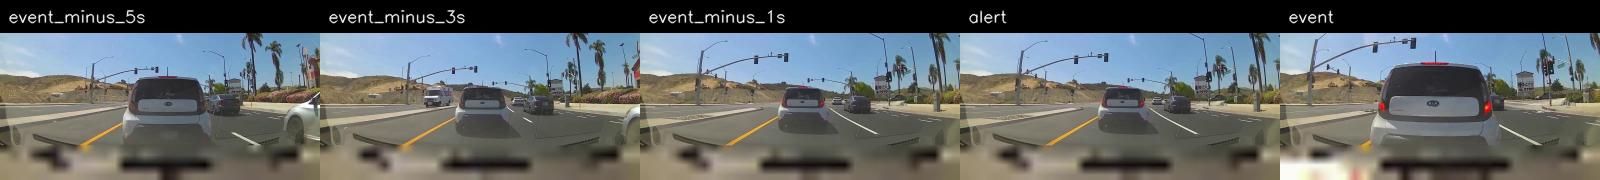

In [4]:
for figure_path in sorted(FIGURES_DIR.glob("*timeline*.png")):
    print(figure_path.name)
    display(Image(filename=str(figure_path)))

## **Positive vs Negative Example**

This side-by-side image provides an initial visual comparison between an event frame and a regular driving frame.

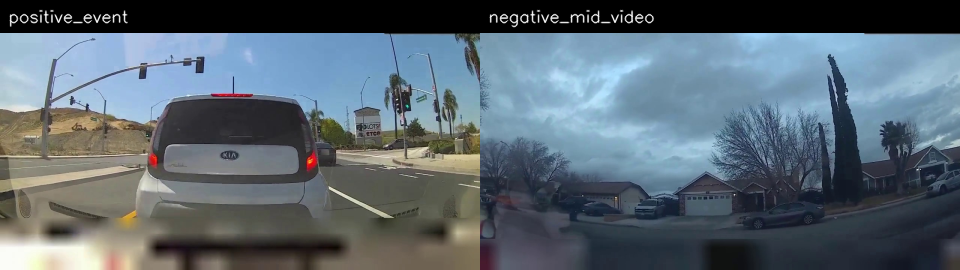

In [5]:
comparison_path = FIGURES_DIR / "positive_vs_negative_example.png"
display(Image(filename=str(comparison_path)))

## **Notes for the Article**

- The sampled frame strategy supports a qualitative inspection before model training.
- Positive examples should be analyzed relative to event timing, not only as isolated frames.
- The baseline should be presented as a controlled reference method before temporal models.
- Visual examples can support the dataset and methodology sections of the article.